In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")

payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

rfm_segments = pd.read_csv(
    BASE_DIR / "data/processed/rfm_segments.csv"
)


In [27]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [28]:
rfm = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

rfm = rfm.merge(
    payments,
    on="order_id",
    how="left"
)
rfm.head()
rfm.shape


(103887, 16)

In [29]:
rfm['order_purchase_timestamp'].max()

Timestamp('2018-10-17 17:30:18')

In [30]:
snapshot_date = rfm['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2018-10-18 17:30:18')

In [31]:
rfm_table = rfm.groupby(
    'customer_unique_id'
).agg({
    'order_purchase_timestamp':
        lambda x: (snapshot_date - x.max()).days,

    'order_id': 'nunique',

    'payment_value': 'sum'
})

In [32]:
rfm_table.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]
rfm_table.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
0000f46a3911fa3c0805444483337064,586,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [33]:
rfm_table.describe()

,Recency,Frequency,Monetary
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,166.592492
std,153.414676,0.214384,231.428332
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,63.120000
50%,269.000000,1.000000,108.000000
75%,398.000000,1.000000,183.530000
max,773.000000,17.000000,13664.080000


In [34]:
rfm['order_purchase_timestamp'].max()

Timestamp('2018-10-17 17:30:18')

In [35]:
snapshot_date = rfm['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [36]:
rfm_table.describe()

,Recency,Frequency,Monetary
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,166.592492
std,153.414676,0.214384,231.428332
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,63.120000
50%,269.000000,1.000000,108.000000
75%,398.000000,1.000000,183.530000
max,773.000000,17.000000,13664.080000


# RFM Analysis Findings

## Recency

Average Recency: 289 days

Insight:
Customers tend to have long periods between purchases, indicating opportunities for retention campaigns.

---

## Frequency

Average Frequency: 1.03 orders

Insight:
Most customers are one-time buyers, highlighting the need to improve repeat purchasing behavior.

---

## Monetary

Average Monetary Value: $166.59

Insight:
A small segment of customers generates significantly higher revenue than the average customer.

In [37]:
rfm_table['R_Score'] = pd.qcut(
    rfm_table['Recency'],
    4,
    labels=[4,3,2,1]
)

rfm_table['F_Score'] = pd.qcut(
    rfm_table['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm_table['M_Score'] = pd.qcut(
    rfm_table['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [38]:
rfm_table['RFM_Score'] = (
    rfm_table['R_Score'].astype(str) +
    rfm_table['F_Score'].astype(str) +
    rfm_table['M_Score'].astype(str)
)

In [39]:
rfm_table.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,3,413
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411
0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,214


In [40]:
def segment_customer(row):

    if row['RFM_Score'] == '444':
        return 'Champions'

    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'

    elif row['R_Score'] >= 3:
        return 'Potential Loyalists'

    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'At Risk'

    else:
        return 'Others'

In [41]:
rfm_table['Segment'] = rfm_table.apply(
    segment_customer,
    axis=1
)

In [42]:
rfm_table['Segment'].value_counts()

Segment
At Risk                24081
Potential Loyalists    23967
Others                 23940
Loyal Customers        22247
Champions               1861
Name: count, dtype: int64

# Customer Segmentation Findings

## Champions
1,861 customers

Business Action:
Provide VIP rewards, loyalty programs, and premium offers.

---

## Loyal Customers
22,247 customers

Business Action:
Focus on retention and cross-selling.

---

## Potential Loyalists
23,967 customers

Business Action:
Encourage repeat purchases through targeted promotions.

---

## At Risk Customers
24,081 customers

Business Action:
Launch re-engagement campaigns and personalized discounts.

In [43]:
plt.figure(figsize=(10,6))

segment_counts.plot(kind='bar')

plt.title("Customer Segmentation Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

for i, v in enumerate(segment_counts):
    plt.text(i, v + 200, str(v), ha='center')

plt.tight_layout()
plt.show()

NameError: name 'segment_counts' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
rfm_table.reset_index(inplace=True)

In [ ]:
customer_segments = rfm_table[
    ['customer_unique_id', 'Segment', 'Monetary']
]

In [ ]:
customer_segments.head()

,customer_unique_id,Segment,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,Potential Loyalists,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,Potential Loyalists,27.19
2,0000f46a3911fa3c0805444483337064,At Risk,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,At Risk,43.62
4,0004aac84e0df4da2b147fca70cf8255,At Risk,196.89


In [ ]:
segment_revenue = customer_segments.groupby(
    'Segment'
)['Monetary'].sum().sort_values(ascending=False)

segment_revenue

Segment
Others                 4035586.97
At Risk                3905914.14
Potential Loyalists    3874006.05
Loyal Customers        3414331.23
Champions               779033.73
Name: Monetary, dtype: float64

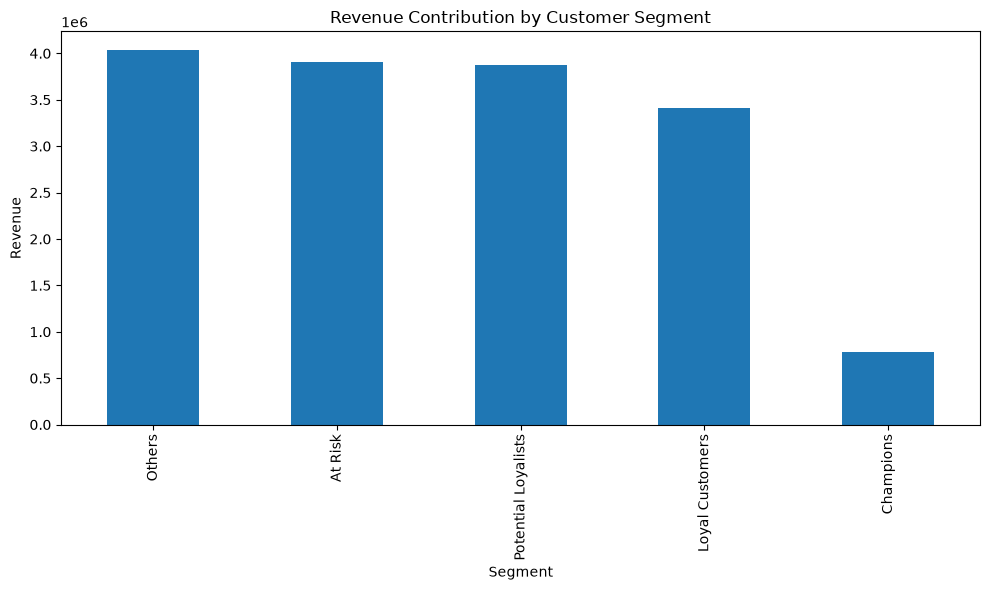

In [ ]:
plt.figure(figsize=(10,6))

segment_revenue.plot(kind='bar')

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [ ]:
rfm_table['CLV'] = (
    rfm_table['Frequency'] *
    rfm_table['Monetary']
)

In [ ]:
rfm_table[['Frequency','Monetary','CLV']].head()

,Frequency,Monetary,CLV
0,1,141.90,141.90
1,1,27.19,27.19
2,1,86.22,86.22
3,1,43.62,43.62
4,1,196.89,196.89


In [ ]:
top_customers = rfm_table.sort_values(
    'CLV',
    ascending=False
).head(10)

top_customers[
    ['Recency','Frequency','Monetary','CLV','Segment']
]

,Recency,Frequency,Monetary,CLV,Segment
26456,61,3,9553.02,28659.06,Champions
75269,71,4,4655.91,18623.64,Champions
52973,58,17,927.63,15769.71,Champions
81962,565,2,7571.63,15143.26,Others
3826,384,1,13664.08,13664.08,At Risk
23472,232,9,1172.66,10553.94,Loyal Customers
2032,456,2,4053.08,8106.16,Others
95534,119,5,1590.76,7953.80,Champions
76082,139,7,1122.72,7859.04,Champions
44447,95,1,7274.88,7274.88,Potential Loyalists


In [ ]:
%whos

Variable           Type         Data/Info
-----------------------------------------
customers          DataFrame    Shape: (99441, 5)
np                 module       <module 'numpy' from 'e:\<...>ges\\numpy\\__init__.py'>
orders             DataFrame    Shape: (99441, 8)
payments           DataFrame    Shape: (103886, 5)
pd                 module       <module 'pandas' from 'e:<...>es\\pandas\\__init__.py'>
plt                module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
rfm                DataFrame    Shape: (103887, 16)
rfm_table          DataFrame    Shape: (96096, 8)
segment_customer   function     <function segment_customer at 0x0000020F20BDE8E0>
snapshot_date      Timestamp    2018-10-18 17:30:18
sns                module       <module 'seaborn' from 'e<...>s\\seaborn\\__init__.py'>


In [ ]:
rfm_table.to_csv(
    "../data/processed/rfm_segments.csv",
    index=False
)

In [ ]:
import os

os.makedirs("../data/processed", exist_ok=True)

rfm_table.to_csv(
    "../data/processed/rfm_segments.csv",
    index=False
)

In [ ]:
import os

print(os.path.exists("../data/processed/rfm_segments.csv"))

True


In [44]:
print(rfm_table.columns)

Index(['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score',
       'RFM_Score', 'Segment'],
      dtype='str')
